> ⚠️ **DE-LEAKED 정직본** — 누설 5개 제거(112변수) 재실행. RF 잔차지도 등 모델 기반 시각화는 정직 모델 사용.

# 06. 지도 시각화 (v2 — 신규 변수 지도 4개 추가)

자치구 단위 데이터를 GeoJSON 폴리곤에 색칠해 보고서에 인용. 9개 지도 생성.

In [1]:
# === matplotlib 만으로 choropleth 직접 구현 — 외부 GIS 라이브러리 안 씀 ===
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, platform
from matplotlib.patches import Polygon                    # 폴리곤 도형
from matplotlib.collections import PatchCollection         # 여러 폴리곤을 한 번에 추가
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
GEOJSON = PROJECT_ROOT / 'data' / 'raw' / 'seoul_districts.geojson'   # 25개 자치구 경계

df = pd.read_csv(PROCESSED_DIR / 'features.csv')
integ = pd.read_csv(PROCESSED_DIR / 'integrated.csv')

# GeoJSON 로드 — 표준 JSON 구조라 json 모듈만으로 충분
with open(GEOJSON, encoding='utf-8') as f:
    geo = json.load(f)
print('features:', df.shape, '| integrated:', integ.shape, '| polygons:', len(geo['features']))

features: (17568, 164) | integrated: (22099, 83) | polygons: 25


## 1. Choropleth 헬퍼 함수

In [2]:
def polygon_centroid(coords_list):
    """폴리곤 좌표 평균 → 자치구 이름표를 그릴 중심점."""
    arr = np.array(coords_list[0])      # 외곽 링만 사용
    return arr[:,0].mean(), arr[:,1].mean()

def choropleth(ax, gu_values, cmap='YlOrRd', vmin=None, vmax=None, title=''):
    """공통 헬퍼 — gu_values 딕셔너리 {자치구명: 값} 으로 색칠.

    1. GeoJSON feature를 순회하며 Polygon 객체 생성
    2. 자치구명 → 값 매핑으로 색상 결정
    3. 각 자치구 중심에 '이름 + 값' 라벨
    """
    patches, vals = [], []
    for feat in geo['features']:
        # GeoJSON property에서 자치구명 추출 (SIG_KOR_NM 또는 name)
        name = feat['properties'].get('SIG_KOR_NM') or feat['properties'].get('name')
        geom = feat['geometry']
        # Polygon vs MultiPolygon 분기
        polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for poly in polys:
            patches.append(Polygon(poly[0], closed=True))
            vals.append(gu_values.get(name, np.nan))
    vals = np.array(vals, dtype=float)
    if vmin is None: vmin = np.nanmin(vals)
    if vmax is None: vmax = np.nanmax(vals)
    # PatchCollection로 모두 한 번에 add (개별 add보다 빠름)
    coll = PatchCollection(patches, cmap=cmap, edgecolor='gray', linewidth=0.5)
    coll.set_array(vals); coll.set_clim(vmin, vmax)
    ax.add_collection(coll)
    # 자치구 중심에 라벨
    for feat in geo['features']:
        name = feat['properties'].get('SIG_KOR_NM') or feat['properties'].get('name')
        geom = feat['geometry']
        cx, cy = polygon_centroid(geom['coordinates']) if geom['type'] == 'Polygon' \
                 else polygon_centroid(geom['coordinates'][0])
        v = gu_values.get(name, np.nan)
        label = name if np.isnan(v) else f'{name}\n{v:.2f}'
        ax.annotate(label, (cx, cy), ha='center', va='center', fontsize=6.5)
    ax.autoscale_view(); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    return coll

print('helper ready')

helper ready


## 지도 1 — 자치구 평균 매출 (log)

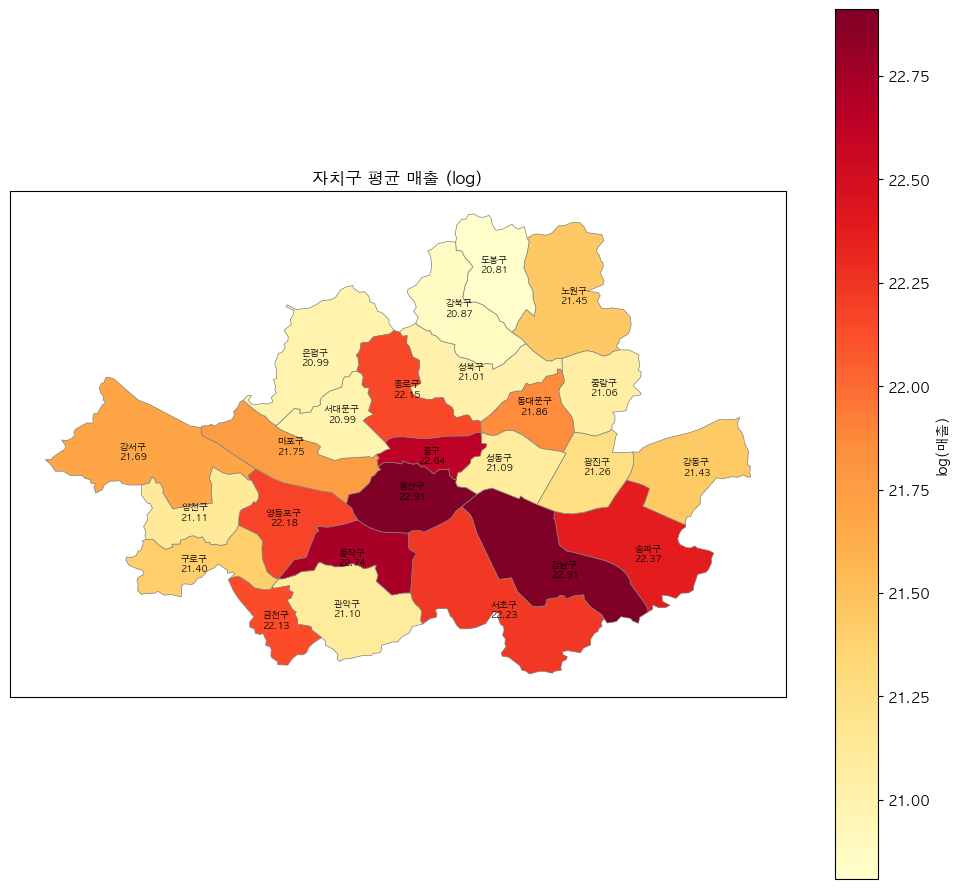

In [3]:
# 매출은 long-tail → log 변환 후 색칠
val = np.log(integ.groupby('gu')['THSMON_SELNG_AMT'].mean().clip(lower=1)).to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, val, 'YlOrRd', title='자치구 평균 매출 (log)')
plt.colorbar(c, ax=ax, label='log(매출)'); plt.tight_layout(); plt.show()

## 지도 2 — RF 모델 잔차

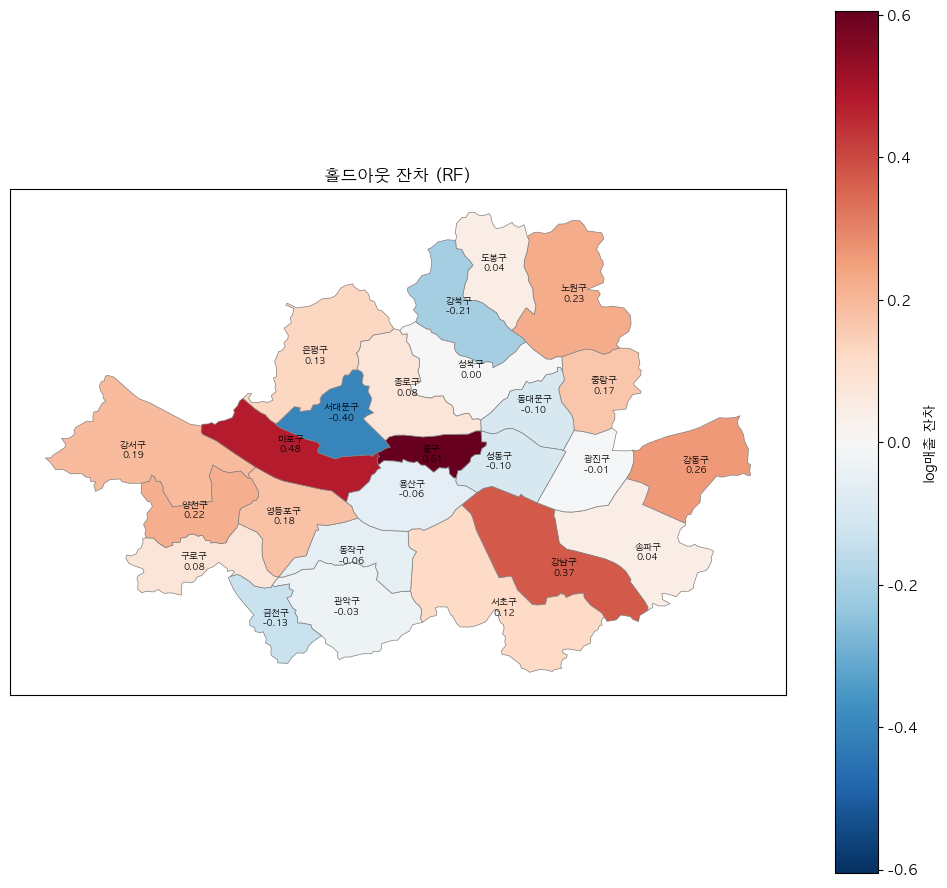

In [4]:
# 잔차 = 실제 - 예측. 양수면 모델 과소예측, 음수면 과대예측
from sklearn.ensemble import RandomForestRegressor
id_cols = ['gu','biz','q','q_int']
target = 'log_sales'
feature_cols = [c for c in df.columns if c not in id_cols + ['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class']]
feature_cols = [c for c in feature_cols if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(feature_cols)
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean(numeric_only=True))

train_mask = df['q_int'] < 20241
hold_mask  = df['q_int'] >= 20241
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(df.loc[train_mask, feature_cols], df.loc[train_mask, target])
pred = rf.predict(df.loc[hold_mask, feature_cols])
resid = df.loc[hold_mask, target].values - pred
# 자치구별 잔차 평균
resid_by_gu = pd.Series(resid, index=df.loc[hold_mask, 'gu'].values).groupby(level=0).mean().to_dict()

fig, ax = plt.subplots(figsize=(10, 9))
m = max(abs(v) for v in resid_by_gu.values())
c = choropleth(ax, resid_by_gu, 'RdBu_r', vmin=-m, vmax=m, title='홀드아웃 잔차 (RF)')
plt.colorbar(c, ax=ax, label='log매출 잔차'); plt.tight_layout(); plt.show()

## 지도 3 — anchor_score

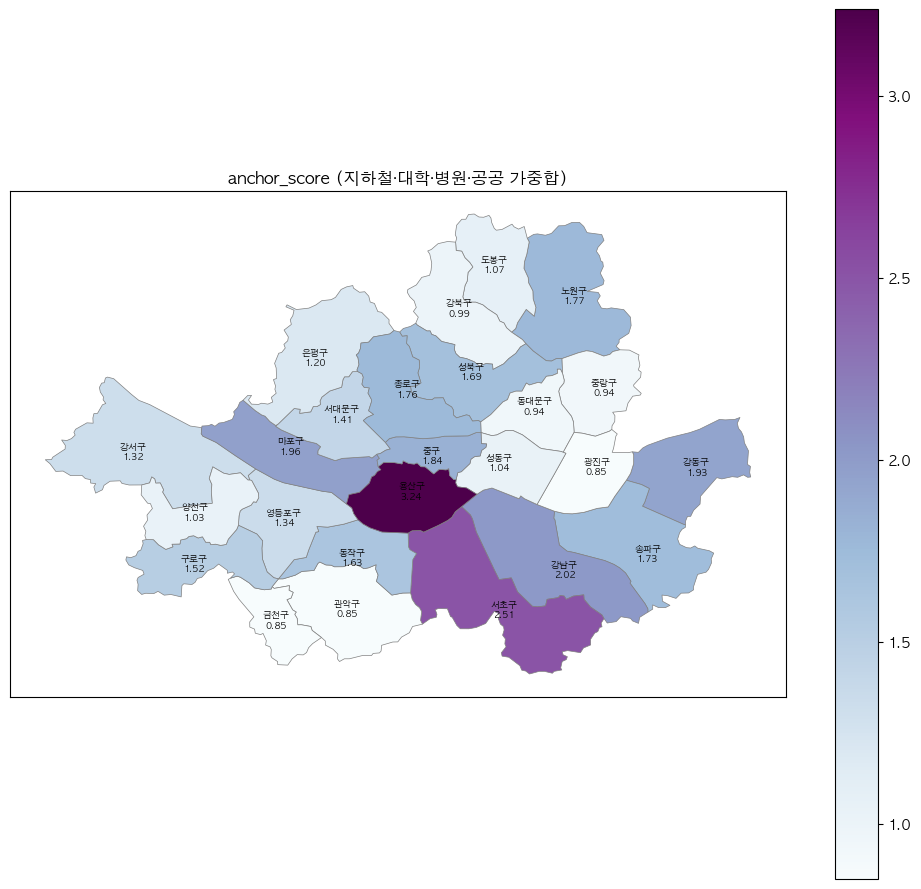

In [5]:
anchor = df.groupby('gu')['anchor_score'].mean().to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, anchor, 'BuPu', title='anchor_score (지하철·대학·병원·공공 가중합)')
plt.colorbar(c, ax=ax); plt.tight_layout(); plt.show()

## 지도 4 — age_entropy

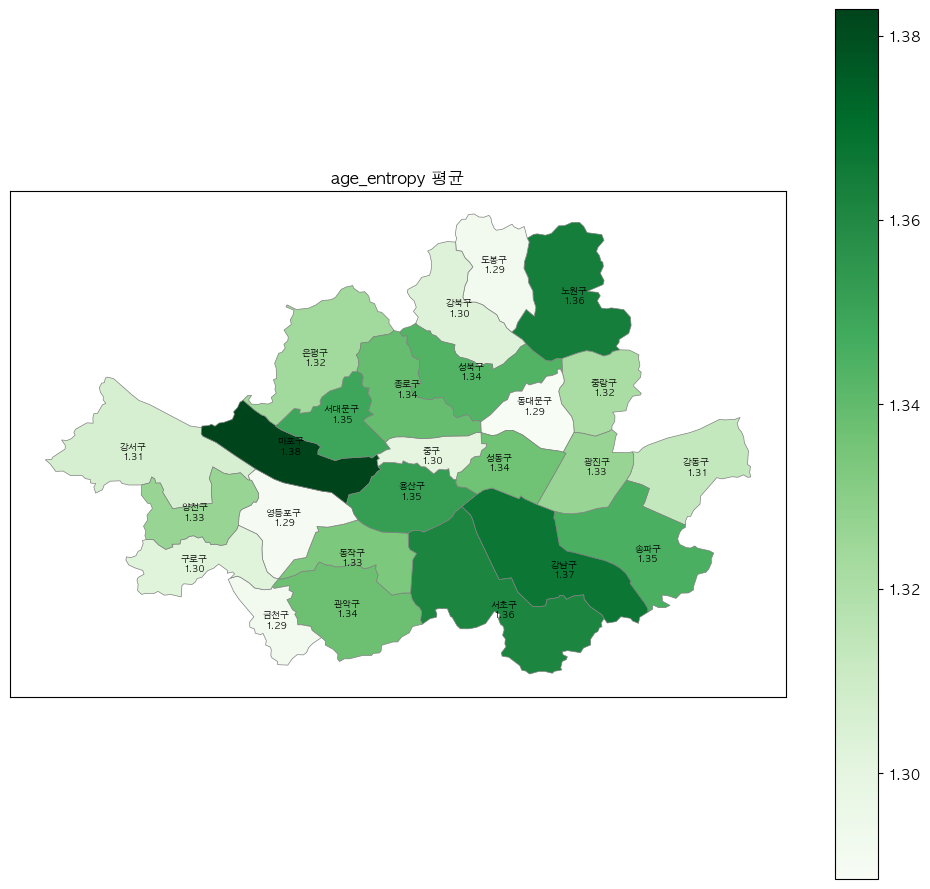

In [6]:
# 변수 중요도 상위 변수가 지리적으로 어떻게 분포하는지
ae = df.groupby('gu')['age_entropy'].mean().to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, ae, 'Greens', title='age_entropy 평균')
plt.colorbar(c, ax=ax); plt.tight_layout(); plt.show()

## 지도 5 — 공실률 (신규)

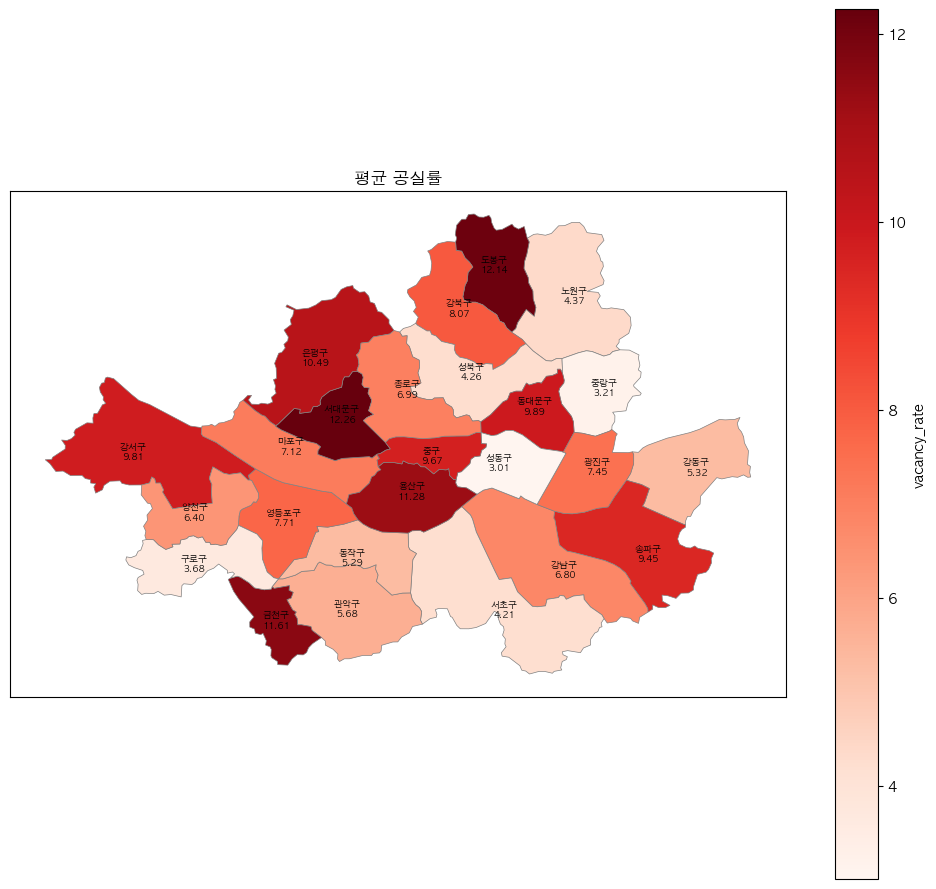

In [7]:
vac = integ.dropna(subset=['vacancy_rate']).groupby('gu')['vacancy_rate'].mean().to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, vac, 'Reds', title='평균 공실률')
plt.colorbar(c, ax=ax, label='vacancy_rate'); plt.tight_layout(); plt.show()

## 지도 6 — 임대료지수 (신규)

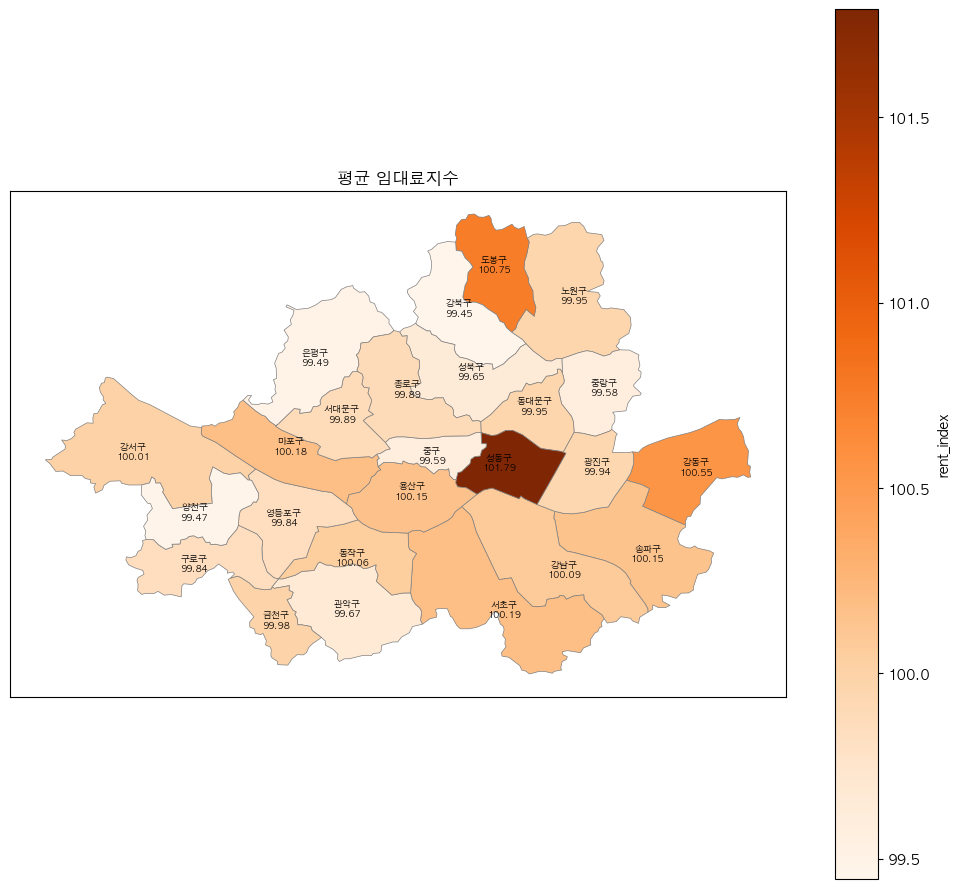

In [8]:
rent = integ.dropna(subset=['rent_index_q']).groupby('gu')['rent_index_q'].mean().to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, rent, 'Oranges', title='평균 임대료지수')
plt.colorbar(c, ax=ax, label='rent_index'); plt.tight_layout(); plt.show()

## 지도 7 — 인구밀도 (신규)

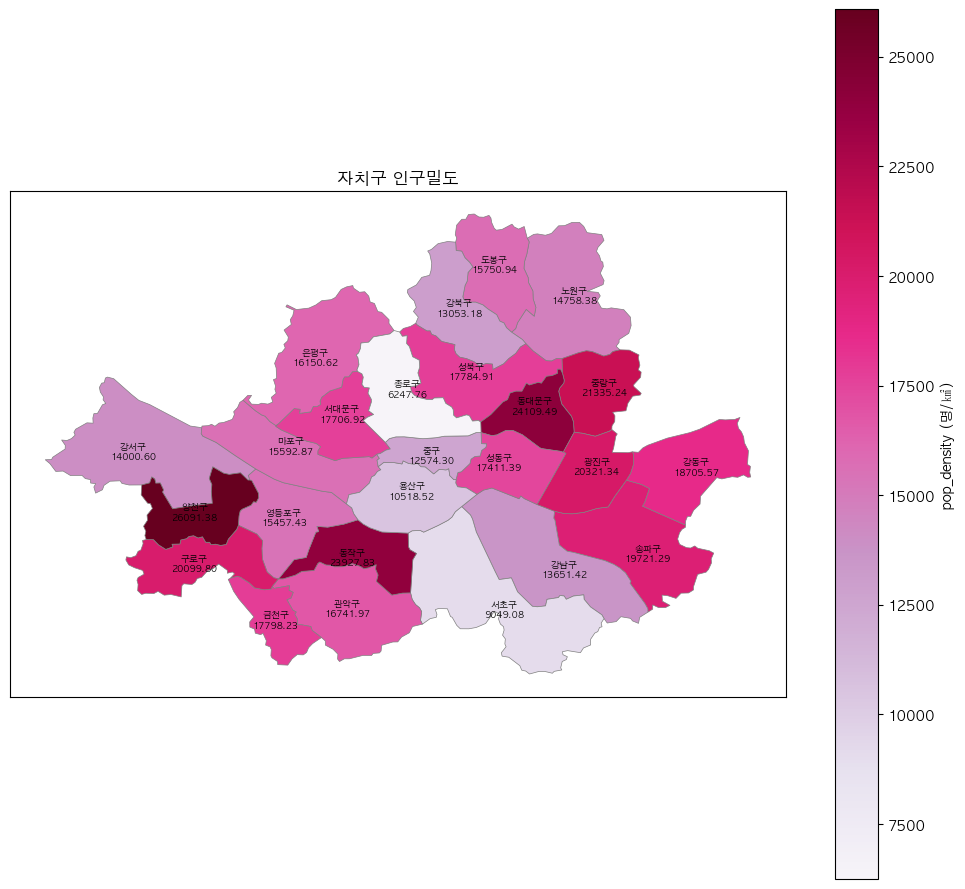

In [9]:
popd = integ.dropna(subset=['gu_pop_density']).groupby('gu')['gu_pop_density'].first().to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, popd, 'PuRd', title='자치구 인구밀도')
plt.colorbar(c, ax=ax, label='pop_density (명/㎢)'); plt.tight_layout(); plt.show()

## 지도 8 — 자치구 평균 폐업점포수 (신규)

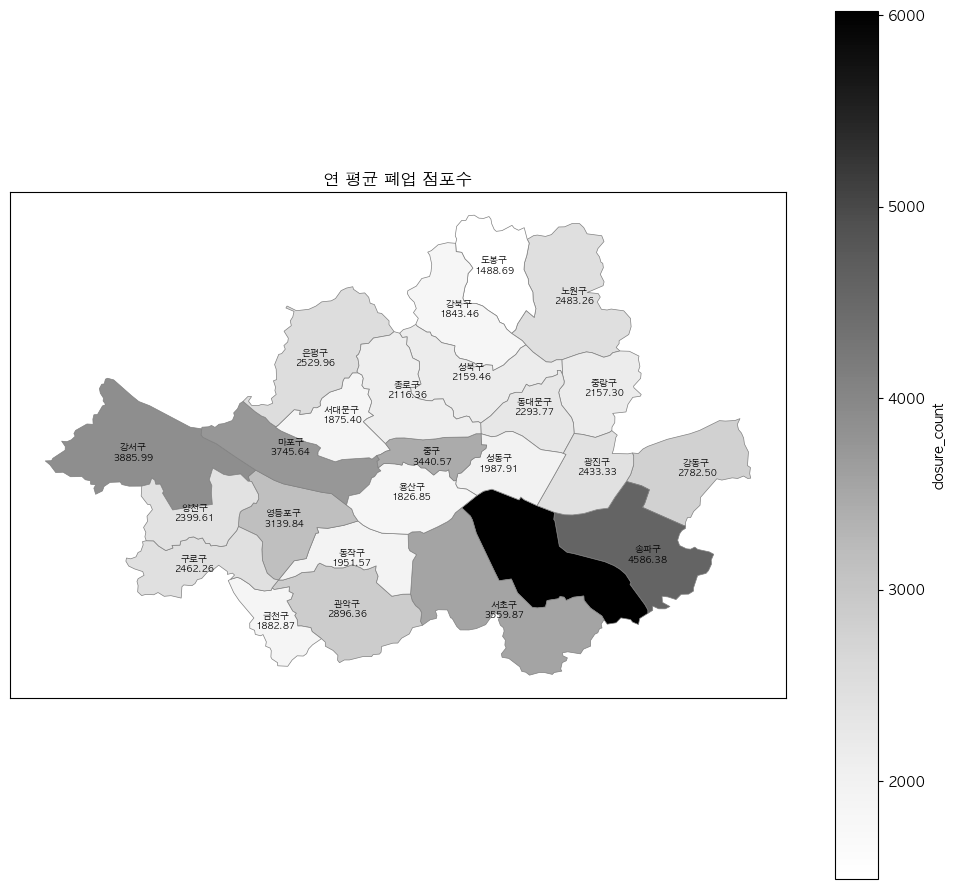

In [10]:
clo = integ.dropna(subset=['closure_count']).groupby('gu')['closure_count'].mean().to_dict()
fig, ax = plt.subplots(figsize=(10, 9))
c = choropleth(ax, clo, 'Greys', title='연 평균 폐업 점포수')
plt.colorbar(c, ax=ax, label='closure_count'); plt.tight_layout(); plt.show()

## 지도 9 — 충격기 vs 회복기 4-패널

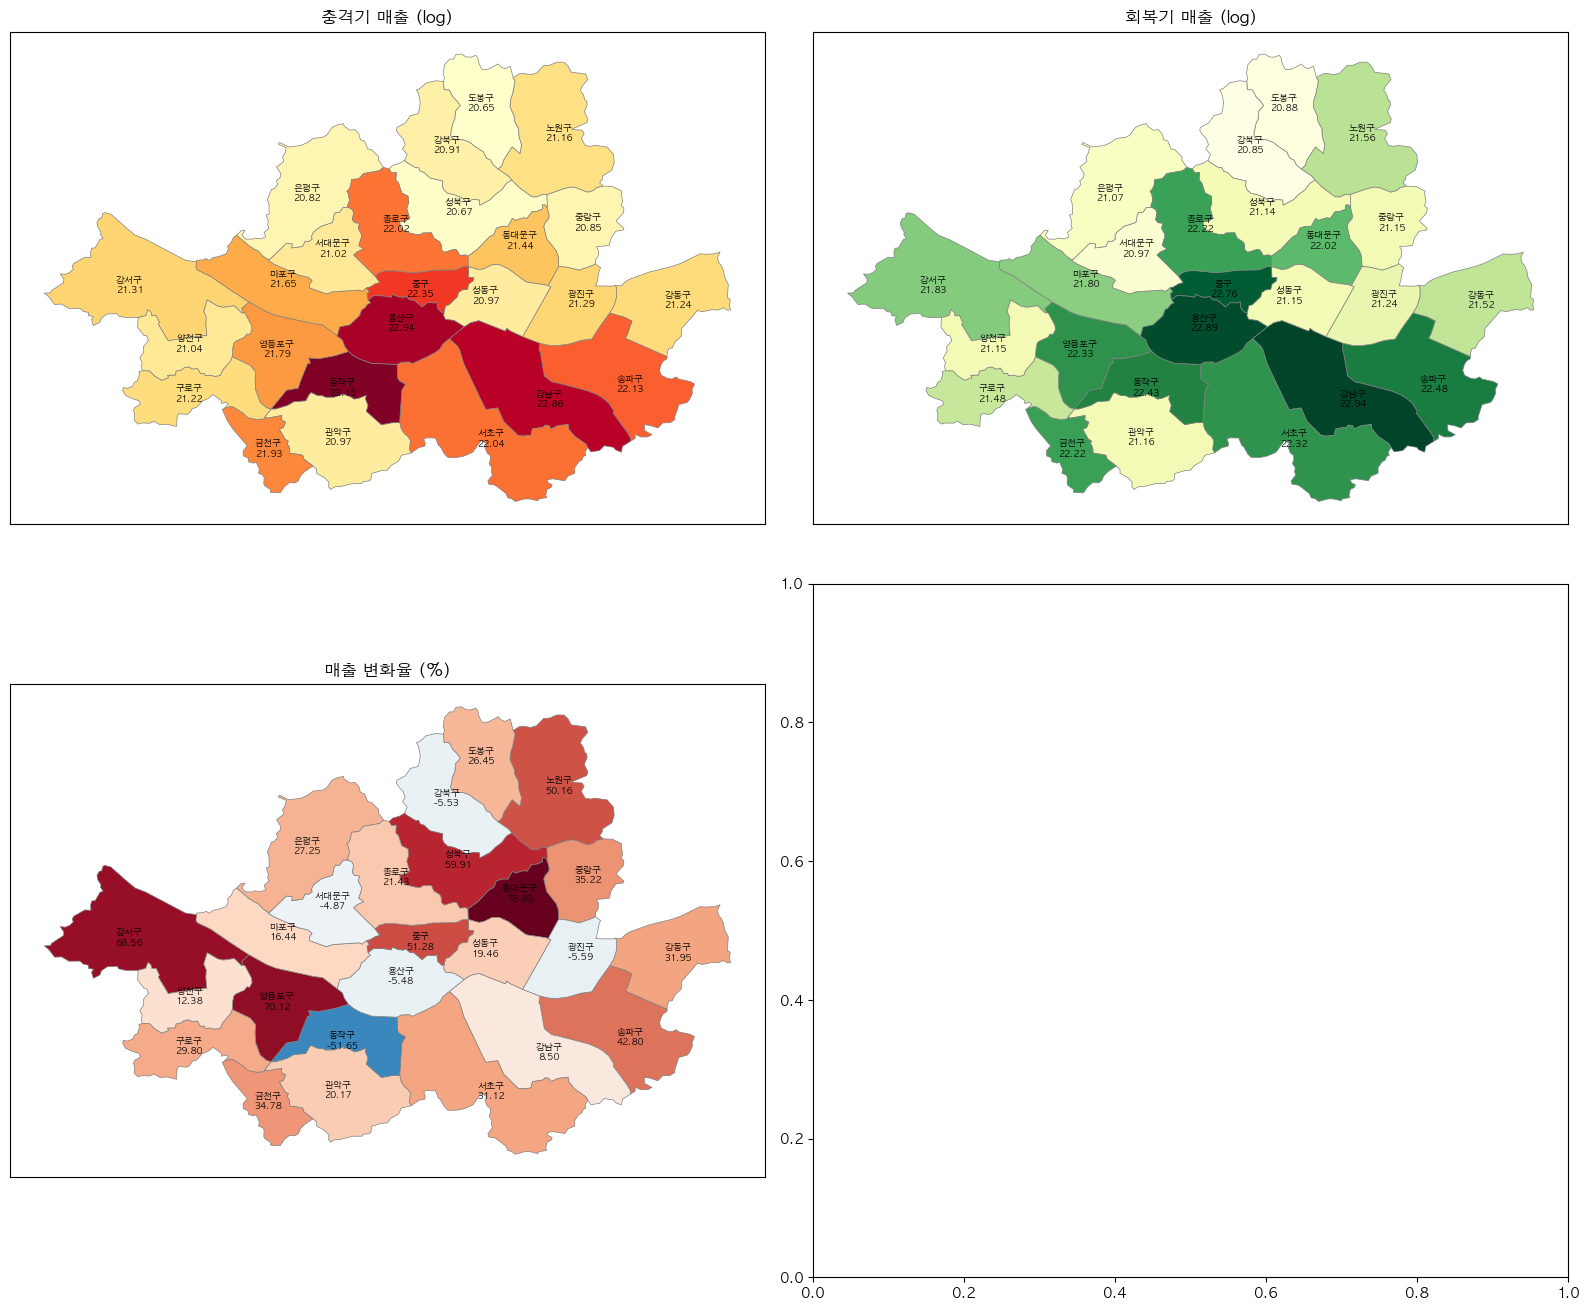

In [11]:
shock = integ[integ['q_int'].between(20201, 20214)].groupby('gu')['THSMON_SELNG_AMT'].mean()
recov = integ[integ['q_int'] >= 20221].groupby('gu')['THSMON_SELNG_AMT'].mean()
chg_pct = ((recov - shock) / shock * 100).fillna(0)        # 회복률 (%)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
choropleth(axes[0,0], np.log(shock).to_dict(),  'YlOrRd', title='충격기 매출 (log)')
choropleth(axes[0,1], np.log(recov).to_dict(),  'YlGn',   title='회복기 매출 (log)')
m = max(abs(chg_pct.min()), abs(chg_pct.max()))
choropleth(axes[1,0], chg_pct.to_dict(), 'RdBu_r', vmin=-m, vmax=m, title='매출 변화율 (%)')

# 공실률 변화 (신규 지표) — 회복기 - 충격기
vac_chg = (integ.assign(phase=lambda d: np.where(d['q_int']<20221,'shock','recov'))
                .dropna(subset=['vacancy_rate'])
                .groupby(['gu','phase'])['vacancy_rate'].mean().unstack('phase'))
if 'recov' in vac_chg.columns and 'shock' in vac_chg.columns:
    vac_delta = (vac_chg['recov'] - vac_chg['shock']).to_dict()
    m2 = max(abs(min(vac_delta.values())), abs(max(vac_delta.values())))
    choropleth(axes[1,1], vac_delta, 'RdBu_r', vmin=-m2, vmax=m2, title='공실률 변화 (회복-충격)')
plt.tight_layout(); plt.show()